##### Part 3 Predictive Modeling


Ultimate is interested in predicting rider retention. To help explore this question, we have provided a sample dataset of a cohort of users who signed up for an Ultimate account in January 2014. The data was pulled several months later; we consider a user retained if they were “active” (i.e. took a trip) in the preceding 30 days.

We would like you to use this data set to help understand what factors are the best predictors for retention, and offer suggestions to operationalize those insights to help Ultimate.

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

In [39]:
#load pandas dataframe from json

df = pd.read_json('../ultimate_data_challenge.json')


In [63]:
df.head()

,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,phone_Unknown,phone_iPhone,city_King's Landing,city_Winterfell,is_active
0,4,2014-01-25,4.7,1.10,2014-06-17,15.4,True,46.2,3.67,5.0,False,True,True,False,1
1,0,2014-01-29,5.0,1.00,2014-05-05,0.0,False,50.0,8.26,5.0,False,False,False,False,0
2,3,2014-01-06,4.3,1.00,2014-01-07,0.0,False,100.0,0.77,5.0,False,True,False,False,0
3,9,2014-01-10,4.6,1.14,2014-06-29,20.0,True,80.0,2.36,4.9,False,True,True,False,1
4,14,2014-01-27,4.4,1.19,2014-03-15,11.8,False,82.4,3.13,4.9,False,False,False,True,0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


In [62]:
df.describe()

,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,surge_pct,weekday_pct,avg_dist,avg_rating_by_driver,is_active
count,50000.000000,50000,50000.000000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.278200,2014-01-16 13:04:20.352000,4.601559,1.074764,2014-04-19 08:02:04.992000256,8.849536,60.926084,5.796827,4.778158,0.376080
min,0.000000,2014-01-01 00:00:00,1.000000,1.000000,2014-01-01 00:00:00,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,2014-01-09 00:00:00,4.500000,1.000000,2014-02-14 00:00:00,0.000000,33.300000,2.420000,4.700000,0.000000
50%,1.000000,2014-01-17 00:00:00,4.700000,1.000000,2014-05-08 00:00:00,0.000000,66.700000,3.880000,5.000000,0.000000
75%,3.000000,2014-01-24 00:00:00,5.000000,1.050000,2014-06-18 00:00:00,8.600000,100.000000,6.940000,5.000000,1.000000
max,125.000000,2014-01-31 00:00:00,5.000000,8.000000,2014-07-01 00:00:00,100.000000,100.000000,160.960000,5.000000,1.000000
std,3.792684,NaN,0.564977,0.222336,NaN,19.958811,37.081503,5.707357,0.445753,0.484405


In [43]:
df.isnull().sum()

city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                      396
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
dtype: int64

In [44]:
# we are going to assume that null values in avg_rating_of_driver and avg_rating_by_driver are due to the user not having spent time to rate their driver or be rated by their driver
# we will fill these null values with the mean of the respective columns so we can keep these rows in our dataset

df['avg_rating_of_driver'].fillna(df['avg_rating_of_driver'].mean(), inplace=True)
df['avg_rating_by_driver'].fillna(df['avg_rating_by_driver'].mean(), inplace=True)
df['phone'].fillna('Unknown', inplace=True)

C:\Users\goatf\AppData\Local\Temp\ipykernel_21044\2797996742.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['avg_rating_of_driver'].fillna(df['avg_rating_of_driver'].mean(), inplace=True)
C:\Users\goatf\AppData\Local\Temp\ipykernel_21044\2797996742.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

In [45]:
df.isnull().sum()

city                      0
trips_in_first_30_days    0
signup_date               0
avg_rating_of_driver      0
avg_surge                 0
last_trip_date            0
phone                     0
surge_pct                 0
ultimate_black_user       0
weekday_pct               0
avg_dist                  0
avg_rating_by_driver      0
dtype: int64

In [46]:
# convert signup_date and last_trip_date to datetime objects
df['signup_date'] = pd.to_datetime(df['signup_date'], format='%Y-%m-%d')
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'], format='%Y-%m-%d')
# city and phones should be strings
df['city'] = df['city'].astype('string')
df['phone'] = df['phone'].astype('string')

In [ ]:
# lets make a feature of active users
df['is_active'] = np.where(df['last_trip_date'] >= pd.to_datetime('2014-06-01'), 1, 0)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   trips_in_first_30_days  50000 non-null  int64         
 1   signup_date             50000 non-null  datetime64[ns]
 2   avg_rating_of_driver    50000 non-null  float64       
 3   avg_surge               50000 non-null  float64       
 4   last_trip_date          50000 non-null  datetime64[ns]
 5   surge_pct               50000 non-null  float64       
 6   ultimate_black_user     50000 non-null  bool          
 7   weekday_pct             50000 non-null  float64       
 8   avg_dist                50000 non-null  float64       
 9   avg_rating_by_driver    50000 non-null  float64       
 10  phone_Unknown           50000 non-null  boolean       
 11  phone_iPhone            50000 non-null  boolean       
 12  city_King's Landing     50000 non-null  boolea

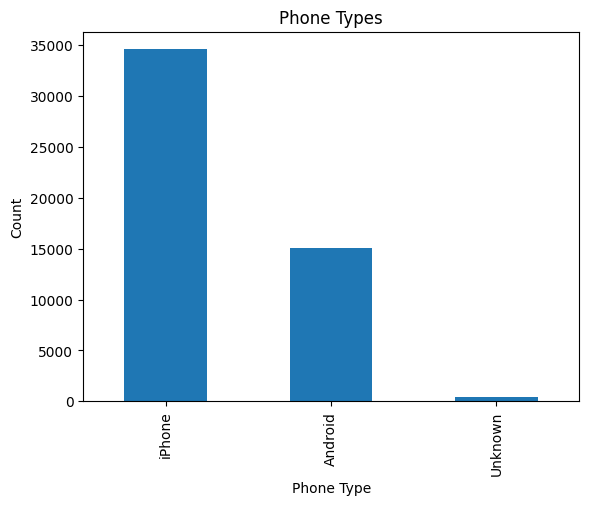

In [48]:
# lets make a bargraph of phone types and then hotencode them
df['phone'].value_counts().plot(kind='bar')
plt.title('Phone Types')
plt.xlabel('Phone Type')
plt.ylabel('Count')
plt.show()

about two thirds of people have an iphone

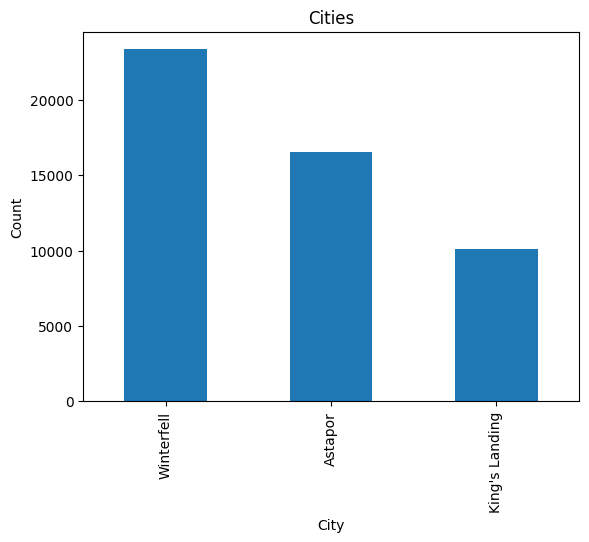

In [49]:
# and cities
df['city'].value_counts().plot(kind='bar')
plt.title('Cities')
plt.xlabel('City')
plt.ylabel('Count')
plt.show()

The majority of people are active in the north. King's Landing has the least amount of users, which makes sense after the fires and the population reduction.

In [50]:
# lets endode phone and city
df = pd.get_dummies(df, columns=['phone', 'city'], drop_first=True)
df.head()

,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,phone_Unknown,phone_iPhone,city_King's Landing,city_Winterfell
0,4,2014-01-25,4.7,1.10,2014-06-17,15.4,True,46.2,3.67,5.0,False,True,True,False
1,0,2014-01-29,5.0,1.00,2014-05-05,0.0,False,50.0,8.26,5.0,False,False,False,False
2,3,2014-01-06,4.3,1.00,2014-01-07,0.0,False,100.0,0.77,5.0,False,True,False,False
3,9,2014-01-10,4.6,1.14,2014-06-29,20.0,True,80.0,2.36,4.9,False,True,True,False
4,14,2014-01-27,4.4,1.19,2014-03-15,11.8,False,82.4,3.13,4.9,False,False,False,True


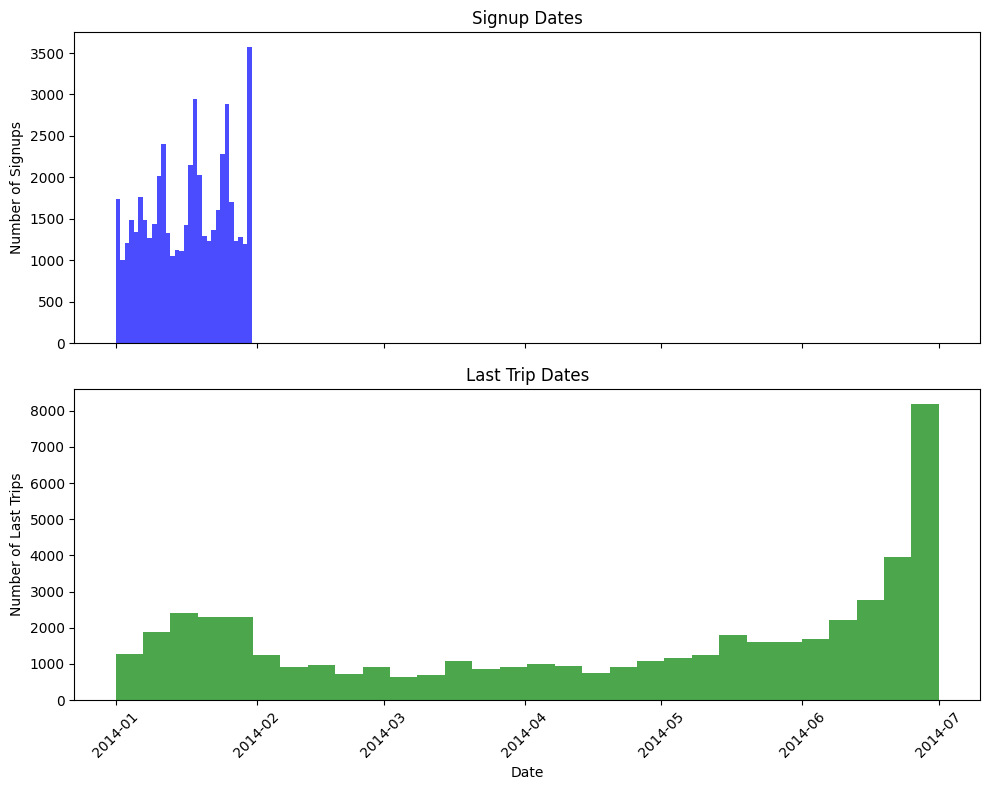

In [52]:
# lets looks at dates when people signed up and last trips dates
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax[0].hist(df['signup_date'], bins=30, color='blue', alpha=0.7)
ax[0].set_title('Signup Dates')
ax[0].set_ylabel('Number of Signups')
ax[1].hist(df['last_trip_date'], bins=30, color='green', alpha=0.7)
ax[1].set_title('Last Trip Dates')
ax[1].set_ylabel('Number of Last Trips')
ax[1].xaxis.set_major_locator(mdates.MonthLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Everyone signed up in January, 4 spikes that probably corrispond to a time in the week.

It looks like the standard last trip date spiked right after signing up in January and then averaged out. 

Everyone in June is still an active user because they used the system in the last 30 days.

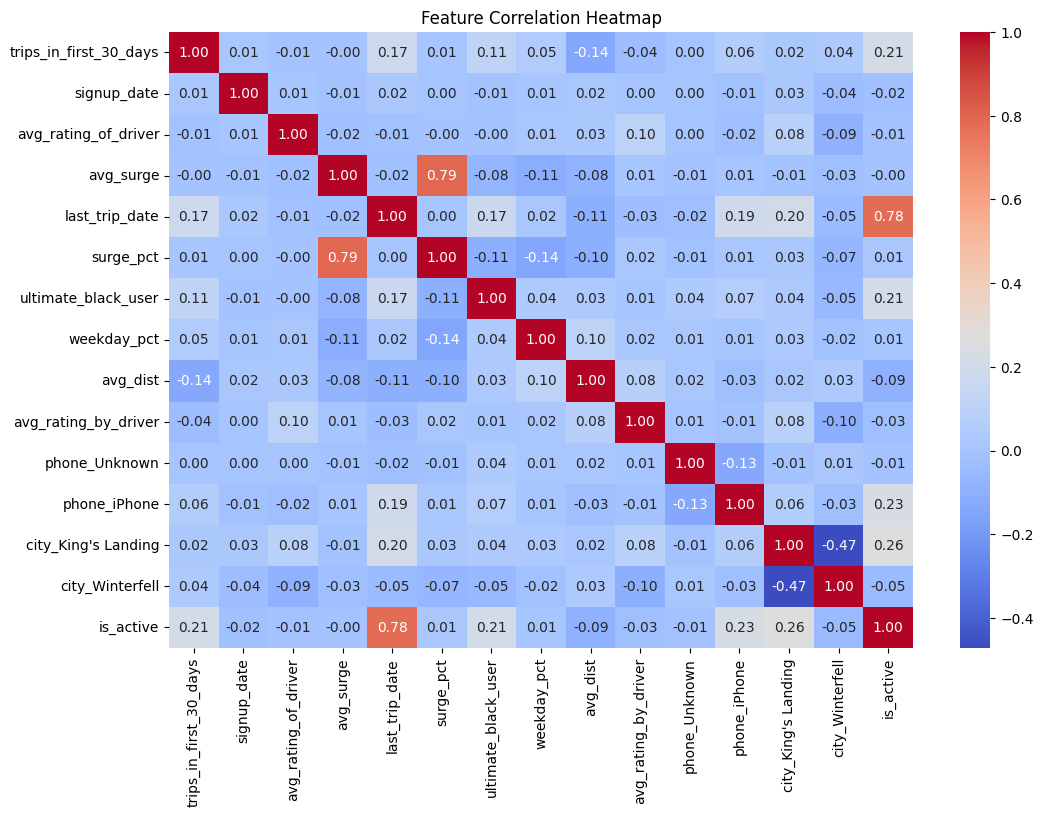

In [64]:
# now we will make a heatmap to see how the features correlate with each other
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Feature Correlation Heatmap')
plt.show()

We want to look at the is_active corrilations ignoring last_trip_date because that is how we calculate our predictive value.

Trips in first 30 days, ultimate black user, iphone user, and King's Landing are the highest corrialting features.

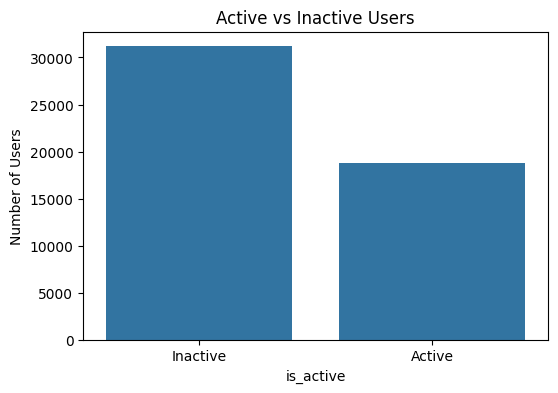

In [60]:
# show total signups vs active users
active_counts = df['is_active'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=active_counts.index, y=active_counts.values)
plt.xticks([0, 1], ['Inactive', 'Active'])
plt.title('Active vs Inactive Users')
plt.ylabel('Number of Users')
plt.show()

about two thirds of people are inactive

#### Part 2 Modeling

Build a predictive model to help Ultimate determine whether or not a user will be active in their 6th month on the system. Discuss why you chose your approach, what alternatives you considered, and any concerns you have. How valid is your model? Include any key indicators of model performance.

In [80]:
#first lets split and scale the data
# drop last_trip_date to prevent data leakage
# drop signup_date because it is not relevant to our prediction
# drop is_active from features because it is our target variable
X = df.drop(columns=['last_trip_date', 'signup_date', 'is_active'])
y = df['is_active']
#now lets scale the data
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
#now lets split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [81]:
# lets start with a logistic regression model

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[7925 1454]
 [2803 2818]]
              precision    recall  f1-score   support

           0       0.74      0.84      0.79      9379
           1       0.66      0.50      0.57      5621

    accuracy                           0.72     15000
   macro avg       0.70      0.67      0.68     15000
weighted avg       0.71      0.72      0.71     15000



In [82]:
# preform k-fold cross validation

scores = cross_val_score(lr, X, y, cv=5)
print(f'Cross-validation scores: {scores}')


Cross-validation scores: [0.7186 0.7185 0.7119 0.7149 0.7237]


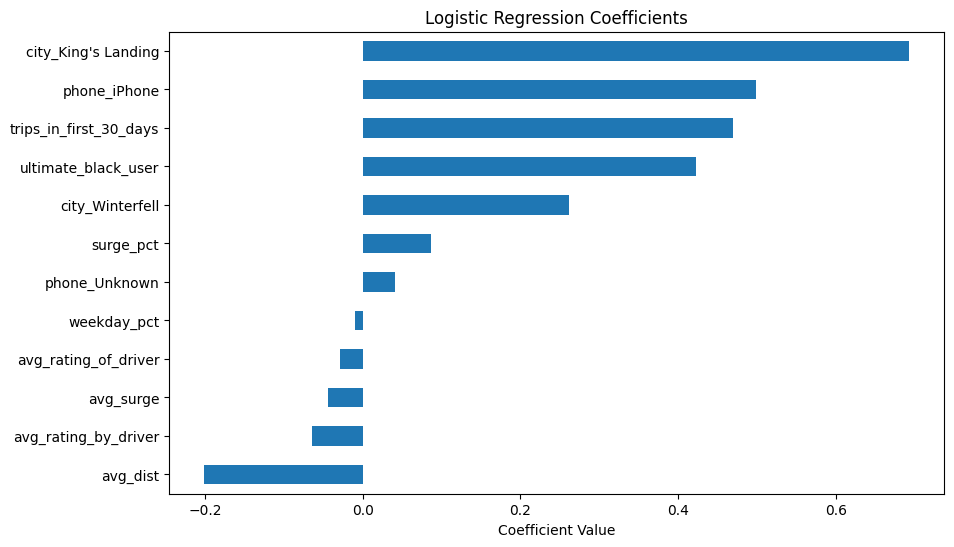

In [83]:
# make a graph of the logistic regression coefficients
coefficients = pd.Series(lr.coef_[0], index=X.columns)
plt.figure(figsize=(10, 6))
coefficients.sort_values().plot(kind='barh')
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.show()

Above you can see the influencing features

Linear regression preformed pretty good at 0.72 accuracy

In [84]:
# now lets try a random forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)
print(confusion_matrix(y_test, rf_y_pred))
print(classification_report(y_test, rf_y_pred))

[[7580 1799]
 [1930 3691]]
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      9379
           1       0.67      0.66      0.66      5621

    accuracy                           0.75     15000
   macro avg       0.73      0.73      0.73     15000
weighted avg       0.75      0.75      0.75     15000



In [85]:
scores = cross_val_score(rf_model, X, y, cv=5)
print(f'Cross-validation scores: {scores}')

Cross-validation scores: [0.7547 0.7501 0.7558 0.7569 0.7571]


Random Forest preforms better than Linear regression at about 0.75 accuracy

In [96]:
# XGBoost Classifier
XGB_model = xgb.XGBClassifier(eval_metric='logloss',
                            random_state=42,
                            max_depth=5,
                            
                            )
XGB_model.fit(X_train, y_train)
XGB_y_pred = XGB_model.predict(X_test)
print(confusion_matrix(y_test, XGB_y_pred))
print(classification_report(y_test, XGB_y_pred))

[[8044 1335]
 [1824 3797]]
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      9379
           1       0.74      0.68      0.71      5621

    accuracy                           0.79     15000
   macro avg       0.78      0.77      0.77     15000
weighted avg       0.79      0.79      0.79     15000



XGBoost has an accuracy of 0.79

In [93]:
# next we can use a neural network

mlp = MLPClassifier(hidden_layer_sizes=(75, 25),
                    max_iter=500,
                    random_state=42,
                    alpha=0.001)

mlp.fit(X_train, y_train)
mlp_y_pred = mlp.predict(X_test)
print(confusion_matrix(y_test, mlp_y_pred))
print(classification_report(y_test, mlp_y_pred))

[[7825 1554]
 [1813 3808]]
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      9379
           1       0.71      0.68      0.69      5621

    accuracy                           0.78     15000
   macro avg       0.76      0.76      0.76     15000
weighted avg       0.77      0.78      0.77     15000



Our neuronet has an accuracy of 0.78

Out of these models I would choose the XGBoost. Because 2 thirds of the system users are inactive, all the models have better statistics for the 0 class (inactive) if you go back and look at the reports. The XGBoost has the highest precision score for the 1 class (active users). So it predicts inactive users at a similar level to the other models, but it is also the most precise at predicting active users.

The neuronet model performs very similarly to the XGBoost, but it has a higher false positive rate for active users and a precision rate of only 71%.

The XGBoost model should be able to predict 79% of the active and inactive users correctly, with a 74% precision rate of active users. It can also be fine tuned to possibly improve those statistics.




## Summary

Based on this information Ultimate can use it to their advantage. The easiest thing to increase their riders is to advertise in Winterfell. The North is stubborn, but if you can unify them, they will all get on board. Ultimate is under-represented in the North.

Targeting certain phone users or updating the app interface may help retention rates as well. Phone type has a strong correlation with retention. That could indicate that the android app version is bad compared to a competitor.

Encouraging people to take more trips after the first 30 days may help retention as well. The highest number of riders went inactive in the first 30 days.

Lastly, have promotions for the ultimate black user. Either the ultimate black users have it because they are more committed riders, or because it is a nice feature and many people don't know its benefits.